# High-Level Backtesting of the ICT Strategy

In [11]:
# imports
import time
import pandas as pd
from nautilus_trader.backtest.config import BacktestVenueConfig, BacktestDataConfig, BacktestRunConfig
from nautilus_trader.backtest.engine import BacktestResult, BacktestEngine, BacktestEngineConfig
from nautilus_trader.backtest.node import BacktestNode
from nautilus_trader.common.config import LoggingConfig
from nautilus_trader.core.datetime import dt_to_unix_nanos
from nautilus_trader.model import BarType, Bar, Venue, InstrumentId
from nautilus_trader.model.enums import OmsType
from nautilus_trader.persistence.catalog import ParquetDataCatalog
from nautilus_trader.persistence.config import DataCatalogConfig
from nautilus_trader.test_kit.providers import TestInstrumentProvider
from nautilus_trader.trading import trader
from nautilus_trader.trading.config import ImportableStrategyConfig
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [ ]:
from core.enums import MoneyManagementType

catalog = ParquetDataCatalog("../catalog")

start_ns = dt_to_unix_nanos(pd.Timestamp("2025-01-01"))
#start_ns = dt_to_unix_nanos(pd.Timestamp("2025-07-09"))
end_ns = dt_to_unix_nanos(pd.Timestamp("2025-10-22"))

instrument = TestInstrumentProvider.es_future(2025, 12)
instrument_id = instrument.id.value

# Configure backtesting
venue = BacktestVenueConfig(
    name="GLBX",
    oms_type=OmsType.NETTING,
    account_type="MARGIN",
    base_currency="USD",
    starting_balances=["30_000 USD"],
)

# Configure a catalog for a live system
catalog_cfg = DataCatalogConfig(
    path=str(catalog.path),
    fs_protocol="file",
    name="local"
)

base_bar_type = BarType.from_str(f"{instrument_id}-1-MINUTE-LAST-EXTERNAL")
weekly_bar_type = BarType.from_str(f"{instrument_id}-1-WEEK-LAST-INTERNAL@1-MINUTE-EXTERNAL")
daily_bar_type = BarType.from_str(f"{instrument_id}-1-DAY-LAST-INTERNAL@1-MINUTE-EXTERNAL")

data = BacktestDataConfig(
    catalog_path=str(catalog.path),
    catalog_fs_protocol="file",
    data_cls=Bar,
    bar_types=[base_bar_type],
    instrument_id=instrument_id,
    start_time=start_ns,
    end_time=end_ns
)

engine = BacktestEngineConfig(
    strategies=[
        ImportableStrategyConfig(
            strategy_path="strategies.ict.ict_strategy:ICTStrategy",
            config_path="strategies.ict.ict_strategy:ICTStrategyConfig",
            config={
                "instrument_id": instrument_id,
                "base_bar_type": base_bar_type,
                "weekly_bar_type": weekly_bar_type,
                "daily_bar_type": daily_bar_type,
                "is_backtest": True,

                # ------------- Liquidity Pool Search -------------
                "liquidity_pool_bar_type": BarType.from_str(f"{instrument_id}-1-DAY-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_lower_timeframe_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_time_delta": pd.Timedelta(hours=24),
                "liquidity_pool_min_lower_timeframe_count": 3,
                "liquidity_pool_extremums_count": 1,
                "liquidity_pool_upper_period_window": 3,
                "liquidity_pool_lower_period_window": 3,

                # ------------- Turtle Soup -------------
                "turtle_soup_analysis_chain_bar_type": [
                    BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                    BarType.from_str(f"{instrument_id}-15-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                    BarType.from_str(f"{instrument_id}-5-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                ],
                "turtle_soup_stop_loss_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "turtle_soup_bars_count": 4,
                "retries_count_on_stop_out": 3,
                "sl_shift": 4.0,

                # ------------- Risk/Reward -------------
                "risk_reward_ratio": 2.0,

                # ------------- Expected Target -------------
                "expected_target_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "expected_target_left": 10,
                "expected_target_right": 10,

                # ------------- Liquidity Pool Reuse -------------
                "liquidity_pool_reuse_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_uses_count": 1,

                # ------------- SMA Exit -------------
                "sma_exit_bar_type": BarType.from_str(f"{instrument_id}-30-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "sma_exit_period": 10,

                # ------------- Money Management -------------
                "money_management_type": MoneyManagementType.FIXED_RISK_PERCENT,
                "fixed_lot": 10.0,
                "fixed_risk_percent": 1.0,
            },
        ),
    ],
    logging=LoggingConfig(log_level="ERROR"),
    catalogs=[catalog_cfg]
)

config = BacktestRunConfig(
    engine=engine,
    venues=[venue],
    data=[data],
)

node = BacktestNode(configs=[config])

# run backtesting
elapsed_start = time.perf_counter()
# Runs one or many configs synchronously
results: list[BacktestResult] = node.run()
elapsed_end = time.perf_counter()

print(f"Elapsed time: {elapsed_end - elapsed_start:.6f} seconds")

Elapsed time: 5.721992 seconds


In [13]:
result = results[0]

print(f"{'='*60}")
print(f"BACKTEST RESULTS")
print(f"{'='*60}")
print(f"Trader ID:        {result.trader_id}")
print(f"Run ID:           {result.run_id}")
print(f"Backtest Period:  {pd.Timestamp(result.backtest_start, unit='ns')} → {pd.Timestamp(result.backtest_end, unit='ns')}")
print(f"Elapsed Time:     {result.elapsed_time / 1e9:.2f} seconds")
print(f"Iterations:       {result.iterations:,}")
print(f"Total Orders:     {result.total_orders}")
print(f"Total Positions:  {result.total_positions}")

print(f"\n{'='*60}")
print(f"PNL STATISTICS (USD)")
print(f"{'='*60}")
pnl = result.stats_pnls.get('USD', {})
print(f"PnL (total):      ${pnl.get('PnL (total)', 0):,.2f}")
print(f"PnL% (total):     {pnl.get('PnL% (total)', 0):.2f}%")
print(f"Expectancy:       ${pnl.get('Expectancy', 0):,.2f}")
print(f"Win Rate:         {pnl.get('Win Rate', 0)*100:.2f}%")
print(f"Max Winner:       ${pnl.get('Max Winner', 0):,.2f}")
print(f"Avg Winner:       ${pnl.get('Avg Winner', 0):,.2f}")
print(f"Min Winner:       ${pnl.get('Min Winner', 0):,.2f}")
print(f"Max Loser:        ${pnl.get('Max Loser', 0):,.2f}")
print(f"Avg Loser:        ${pnl.get('Avg Loser', 0):,.2f}")
print(f"Min Loser:        ${pnl.get('Min Loser', 0):,.2f}")

print(f"\n{'='*60}")
print(f"RETURN STATISTICS")
print(f"{'='*60}")
ret = result.stats_returns
print(f"Sharpe Ratio (252d):   {ret.get('Sharpe Ratio (252 days)', 0):.4f}")
print(f"Sortino Ratio (252d):  {ret.get('Sortino Ratio (252 days)', 0):.4f}")
print(f"Profit Factor:         {ret.get('Profit Factor', 0):.4f}")
print(f"Returns Volatility:    {ret.get('Returns Volatility (252 days)', 0):.4f}")
print(f"Risk Return Ratio:     {ret.get('Risk Return Ratio', 0):.4f}")
print(f"Avg Return:            {ret.get('Average (Return)', 0)*100:.4f}%")
print(f"Avg Win Return:        {ret.get('Average Win (Return)', 0)*100:.4f}%")
print(f"Avg Loss Return:       {ret.get('Average Loss (Return)', 0)*100:.4f}%")

BACKTEST RESULTS
Trader ID:        BACKTESTER-001
Run ID:           ab6fa166-0b72-474a-80fe-0b3d4782a57b
Backtest Period:  2025-07-09 00:00:00 → 2025-10-20 00:00:00
Elapsed Time:     0.01 seconds
Iterations:       100,467
Total Orders:     85
Total Positions:  1

PNL STATISTICS (USD)
PnL (total):      $2,183.50
PnL% (total):     7.28%
Expectancy:       $64.22
Win Rate:         41.18%
Max Winner:       $661.25
Avg Winner:       $602.98
Min Winner:       $555.00
Max Loser:        $-397.25
Avg Loser:        $-312.91
Min Loser:        $-185.25

RETURN STATISTICS
Sharpe Ratio (252d):   3.2954
Sortino Ratio (252d):  6.6672
Profit Factor:         1.5663
Returns Volatility:    0.0724
Risk Return Ratio:     0.1873
Avg Return:            0.0668%
Avg Win Return:        0.4487%
Avg Loss Return:       -0.2006%


In [14]:
backtest_engine: BacktestEngine = node.get_engine(config.id)
positions = backtest_engine.trader.generate_positions_report()

In [15]:
len(positions)

34

In [16]:
pd.set_option("display.max_rows", 202)   # show all rows
pd.set_option("display.max_columns", None)  # show all cols

# Reduce font size for DataFrame display
from IPython.display import display, HTML
display(HTML("<style>.dataframe { font-size: 12px; }</style>"))


In [17]:
positions

,trader_id,strategy_id,instrument_id,account_id,opening_order_id,closing_order_id,entry,side,quantity,peak_qty,ts_init,ts_opened,ts_last,ts_closed,duration_ns,avg_px_open,avg_px_close,commissions,realized_return,realized_pnl,is_snapshot
position_id,,,,,,,,,,,,,,,,,,,,,
ESZ5.GLBX-ICTStrategy-000-c8a84dc1-841a-4352-9037-7cba367cb3f0,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250713-230500-001-000-1,O-20250714-075700-001-000-6,BUY,FLAT,0,61,1752447900000000000,2025-07-13 23:05:00+00:00,1752479820000000000,2025-07-14 07:57:00+00:00,31920000000000,6266.409836,6277.250000,[0.00 USD],0.00173,661.25 USD,True
ESZ5.GLBX-ICTStrategy-000-3fe8bbb3-8222-41e0-a477-b036f53be5f8,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250714-080100-001-000-7,O-20250714-171800-001-000-9,BUY,FLAT,0,16,1752480060000000000,2025-07-14 08:01:00+00:00,1752513480000000000,2025-07-14 17:18:00+00:00,33420000000000,6274.500000,6312.250000,[0.00 USD],0.00602,604.00 USD,True
ESZ5.GLBX-ICTStrategy-000-3afbbbfa-52c7-40b3-b472-8c30f7169a5f,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250716-153000-001-000-10,O-20250716-153000-001-000-11,BUY,FLAT,0,13,1752679860000000000,2025-07-16 15:31:00+00:00,1752680160000000000,2025-07-16 15:36:00+00:00,300000000000,6265.500000,6251.250000,[0.00 USD],-0.00227,-185.25 USD,True
ESZ5.GLBX-ICTStrategy-000-ef2721bf-e983-47bf-86db-2a0b3dc062f6,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250716-154500-001-000-12,O-20250717-135300-001-000-14,BUY,FLAT,0,11,1752680760000000000,2025-07-16 15:46:00+00:00,1752760380000000000,2025-07-17 13:53:00+00:00,79620000000000,6266.500000,6321.250000,[0.00 USD],0.00874,602.25 USD,True
ESZ5.GLBX-ICTStrategy-000-3901ad33-a301-4a55-ac5d-fadfa5f53038,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250722-144500-001-000-15,O-20250723-102400-001-000-17,BUY,FLAT,0,16,1753195500000000000,2025-07-22 14:45:00+00:00,1753266240000000000,2025-07-23 10:24:00+00:00,70740000000000,6334.500000,6371.750000,[0.00 USD],0.00588,596.00 USD,True
ESZ5.GLBX-ICTStrategy-000-7eb4ee7e-70c0-4126-8a66-4148fb5fef9a,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250729-153500-001-000-18,O-20250729-153500-001-000-19,BUY,FLAT,0,36,1753803300000000000,2025-07-29 15:35:00+00:00,1753803780000000000,2025-07-29 15:43:00+00:00,480000000000,6408.750000,6400.000000,[0.00 USD],-0.00137,-315.00 USD,True
ESZ5.GLBX-ICTStrategy-000-97ce514f-cfa8-4c68-9ad6-9a2daef91720,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250729-160000-001-000-20,O-20250729-160000-001-000-21,BUY,FLAT,0,19,1753804860000000000,2025-07-29 16:01:00+00:00,1753901760000000000,2025-07-30 18:56:00+00:00,96900000000000,6413.000000,6396.000000,[0.00 USD],-0.00265,-323.00 USD,True
ESZ5.GLBX-ICTStrategy-000-b947588c-513b-4bcf-b56d-fe6bf6f4c889,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250731-200000-001-000-22,O-20250731-200000-001-000-23,BUY,FLAT,0,18,1753992060000000000,2025-07-31 20:01:00+00:00,1754001540000000000,2025-07-31 22:39:00+00:00,9480000000000,6374.000000,6354.250000,[0.00 USD],-0.00310,-355.50 USD,True
ESZ5.GLBX-ICTStrategy-000-1466c63a-d062-459f-a26d-32f7f8be6bf7,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250805-005500-001-000-24,O-20250805-142300-001-000-26,SELL,FLAT,0,25,1754355300000000000,2025-08-05 00:55:00+00:00,1754403780000000000,2025-08-05 14:23:00+00:00,48480000000000,6367.750000,6343.750000,[0.00 USD],0.00377,600.00 USD,True


In [18]:
# Access portfolio analyzer
portfolio = backtest_engine.portfolio
fills_report = backtest_engine.trader.generate_fills_report()

# Get different categories of statistics
stats_pnls = portfolio.analyzer.get_performance_stats_pnls()
stats_returns = portfolio.analyzer.get_performance_stats_returns()
stats_general = portfolio.analyzer.get_performance_stats_general()

Max drawdown ($): -1,449.25
Max drawdown (%): -4.49%


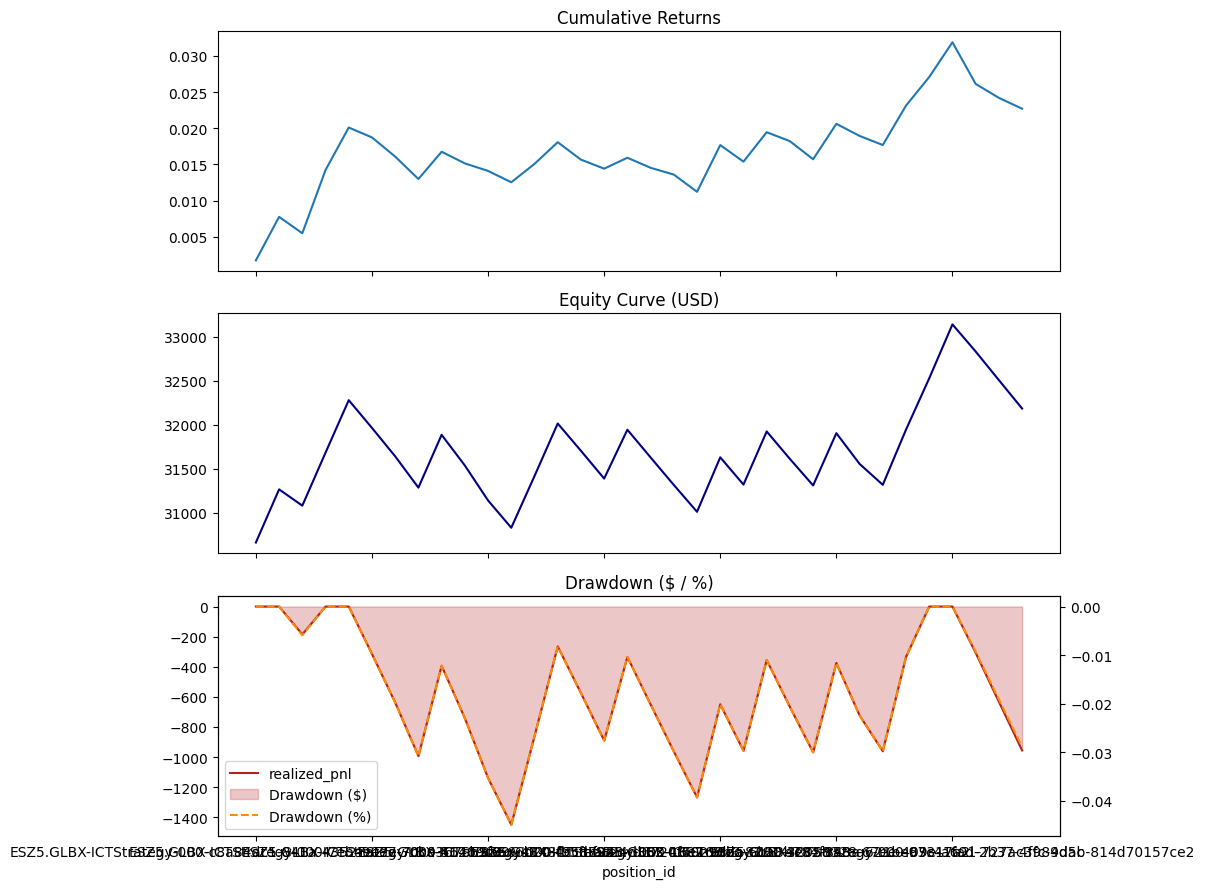

In [19]:
import matplotlib.pyplot as plt


def _money_to_float(series):
    # Convert object/str Money-like series to float values.
    if series.empty:
        return series
    if series.dtype != "O":
        return series
    cleaned = series.astype(str).str.replace(",", "")
    numeric = cleaned.str.split().str[0]
    return pd.to_numeric(numeric, errors="coerce")


positions_report = backtest_engine.trader.generate_positions_report()

if len(positions_report) == 0:
    print("No positions to report.")
else:
    # Cumulative profit in instrument currency
    returns_series = _money_to_float(positions_report["realized_return"])
    returns = returns_series.cumsum()

    # Build equity curve in USD (use realized_pnl if available, otherwise returns)
    starting_balance = 30_000
    if "realized_pnl" in positions_report.columns:
        pnl_series = _money_to_float(positions_report["realized_pnl"])
        equity = pnl_series.cumsum() + starting_balance
    else:
        equity = returns + starting_balance

    peak = equity.cummax()
    drawdown = equity - peak
    drawdown_pct = equity / peak - 1

    print(f"Max drawdown ($): {drawdown.min():,.2f}")
    print(f"Max drawdown (%): {drawdown_pct.min():.2%}")

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    returns.plot(ax=axes[0], title="Cumulative Returns")
    equity.plot(ax=axes[1], color="navy", title="Equity Curve (USD)")

    drawdown.plot(ax=axes[2], color="firebrick", title="Drawdown ($ / %)")
    axes[2].fill_between(drawdown.index, drawdown, 0, color="firebrick", alpha=0.25, label="Drawdown ($)")

    # Twin axis for percentage drawdown overlay
    ax_dd_pct = axes[2].twinx()
    drawdown_pct.plot(ax=ax_dd_pct, color="darkorange", linestyle="--", label="Drawdown (%)")

    # Combine legends for both axes
    lines, labels = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax_dd_pct.get_legend_handles_labels()
    axes[2].legend(lines + lines2, labels + labels2, loc="lower left")

    plt.tight_layout()
    plt.show()
